In [2]:
# 🛒 NeuralRetail - Exploratory Data Analysis
### Amdox Technologies | AMX-DS-2026-04
#**Intern:** Atharva More  
#**Date:** June 2026  
#**Dataset:** UCI Online Retail II

In [3]:
# Import all libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', 50)
plt.style.use('seaborn-v0_8')
print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [4]:
# Load the dataset
df = pd.read_excel(r"C:\Users\Atharva More\Downloads\online_retail_II.xlsx", 
                   sheet_name='Year 2010-2011')

print("✅ Dataset loaded successfully!")
print(f"📊 Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\n📋 Columns: {list(df.columns)}")

✅ Dataset loaded successfully!
📊 Shape: 541910 rows × 8 columns

📋 Columns: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']


In [5]:
# First look at the data
print("📌 First 5 rows:")
df.head()

📌 First 5 rows:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [6]:
# Basic information
print(" Dataset Info:")
print(f"Total Transactions: {df.shape[0]:,}")
print(f"Total Columns: {df.shape[1]}")
print(f"\n Date Range: {df['InvoiceDate'].min()} to {df['InvoiceDate'].max()}")
print(f" Countries: {df['Country'].nunique()}")
print(f" Unique Products: {df['StockCode'].nunique()}")
print(f" Unique Customers: {df['Customer ID'].nunique()}")
print(f"\n Missing Values:\n{df.isnull().sum()}")

 Dataset Info:
Total Transactions: 541,910
Total Columns: 8

 Date Range: 2010-12-01 08:26:00 to 2011-12-09 12:50:00
 Countries: 38
 Unique Products: 4070
 Unique Customers: 4372

 Missing Values:
Invoice             0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
Price               0
Customer ID    135080
Country             0
dtype: int64


In [7]:
# Clean the data
df_clean = df.dropna(subset=['Customer ID'])
df_clean = df_clean[df_clean['Quantity'] > 0]
df_clean = df_clean[df_clean['Price'] > 0]
df_clean['TotalAmount'] = df_clean['Quantity'] * df_clean['Price']
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])
df_clean['Month'] = df_clean['InvoiceDate'].dt.to_period('M')
df_clean['DayOfWeek'] = df_clean['InvoiceDate'].dt.day_name()

print(f"✅ Data cleaned!")
print(f"📊 Clean dataset shape: {df_clean.shape[0]:,} rows")

✅ Data cleaned!
📊 Clean dataset shape: 397,885 rows


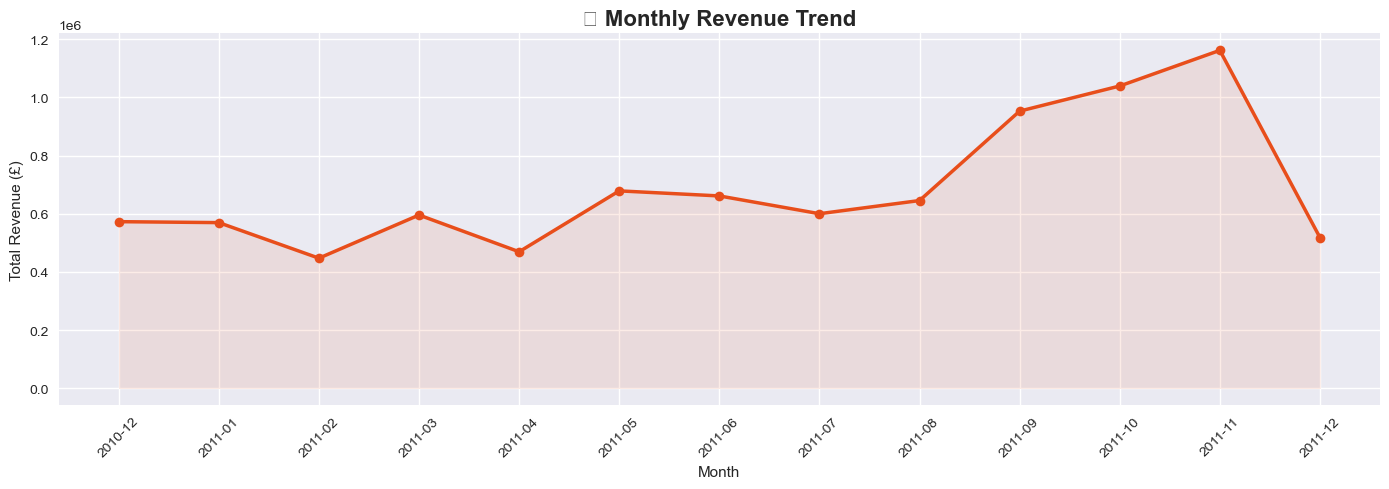

✅ Chart saved!


In [8]:
# Monthly Revenue Trend
monthly_revenue = df_clean.groupby('Month')['TotalAmount'].sum().reset_index()
monthly_revenue['Month'] = monthly_revenue['Month'].astype(str)

plt.figure(figsize=(14, 5))
plt.plot(monthly_revenue['Month'], monthly_revenue['TotalAmount'], 
         marker='o', color='#E84E1B', linewidth=2.5, markersize=7)
plt.fill_between(range(len(monthly_revenue)), monthly_revenue['TotalAmount'], 
                 alpha=0.1, color='#E84E1B')
plt.title('📈 Monthly Revenue Trend', fontsize=16, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Total Revenue (£)')
plt.xticks(range(len(monthly_revenue)), monthly_revenue['Month'], rotation=45)
plt.tight_layout()
plt.savefig(r"C:\Users\Atharva More\NeuralRetail\reports\monthly_revenue.png", dpi=150)
plt.show()
print("✅ Chart saved!")

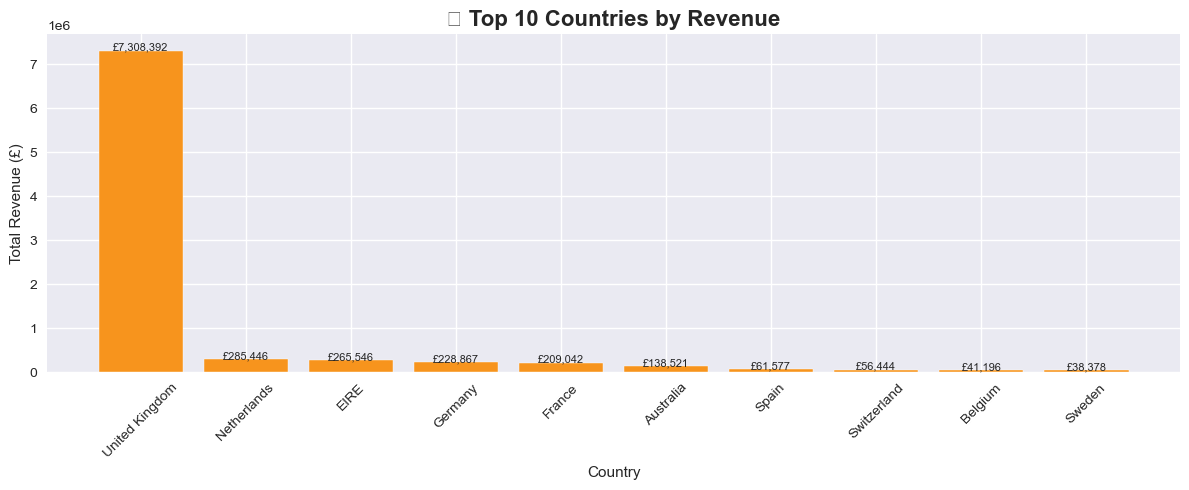

✅ Chart saved!


In [9]:
# Top 10 Countries
top_countries = df_clean.groupby('Country')['TotalAmount'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 5))
bars = plt.bar(top_countries.index, top_countries.values, color='#F7941D', edgecolor='white')
plt.title('🌍 Top 10 Countries by Revenue', fontsize=16, fontweight='bold')
plt.xlabel('Country')
plt.ylabel('Total Revenue (£)')
plt.xticks(rotation=45)
for bar, val in zip(bars, top_countries.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500, 
             f'£{val:,.0f}', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig(r"C:\Users\Atharva More\NeuralRetail\reports\top_countries.png", dpi=150)
plt.show()
print("✅ Chart saved!")

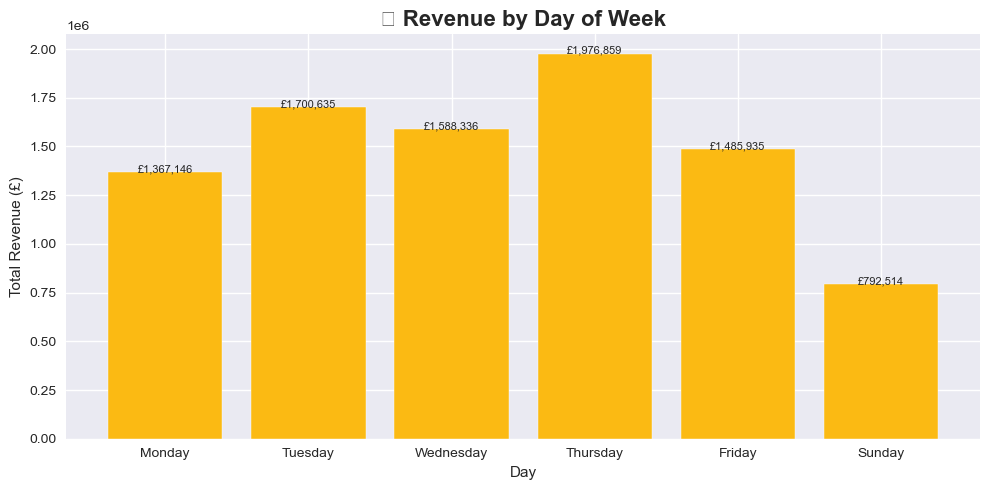

✅ Chart saved!


In [10]:
# Sales by Day of Week
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Sunday']
day_sales = df_clean.groupby('DayOfWeek')['TotalAmount'].sum().reindex(day_order)

plt.figure(figsize=(10, 5))
bars = plt.bar(day_sales.index, day_sales.values, color='#FBBA13', edgecolor='white')
plt.title('📅 Revenue by Day of Week', fontsize=16, fontweight='bold')
plt.xlabel('Day')
plt.ylabel('Total Revenue (£)')
for bar, val in zip(bars, day_sales.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
             f'£{val:,.0f}', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig(r"C:\Users\Atharva More\NeuralRetail\reports\day_of_week.png", dpi=150)
plt.show()
print("✅ Chart saved!")

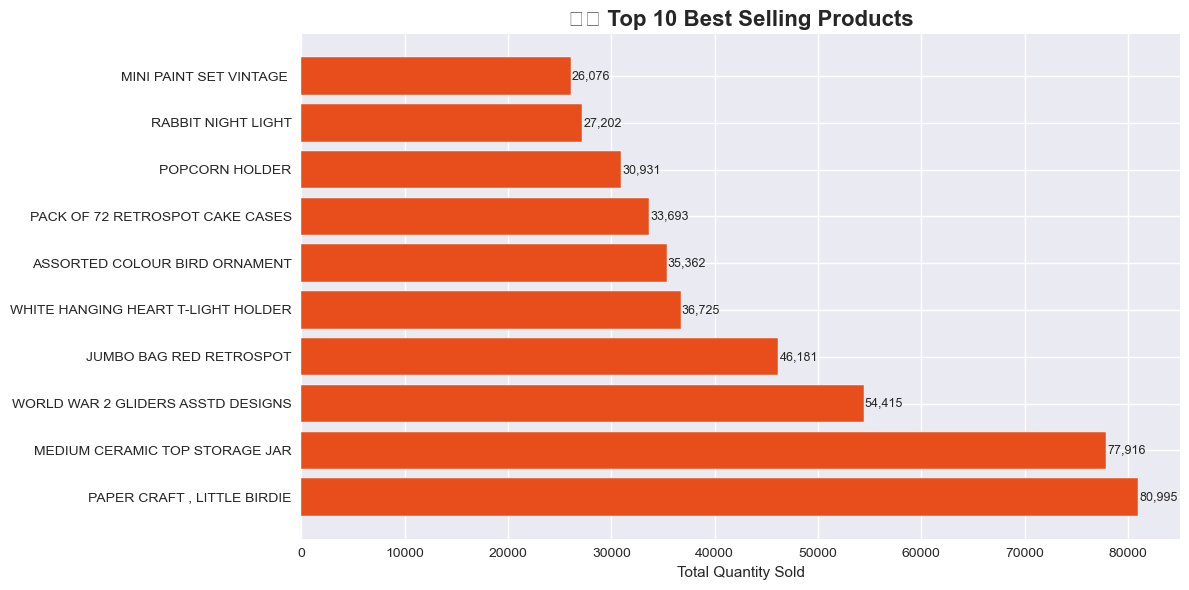

✅ Chart saved!


In [11]:
# Top 10 Best Selling Products
top_products = df_clean.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
bars = plt.barh(top_products.index, top_products.values, color='#E84E1B', edgecolor='white')
plt.title('🛍️ Top 10 Best Selling Products', fontsize=16, fontweight='bold')
plt.xlabel('Total Quantity Sold')
for bar, val in zip(bars, top_products.values):
    plt.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
             f'{val:,}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig(r"C:\Users\Atharva More\NeuralRetail\reports\top_products.png", dpi=150)
plt.show()
print("✅ Chart saved!")

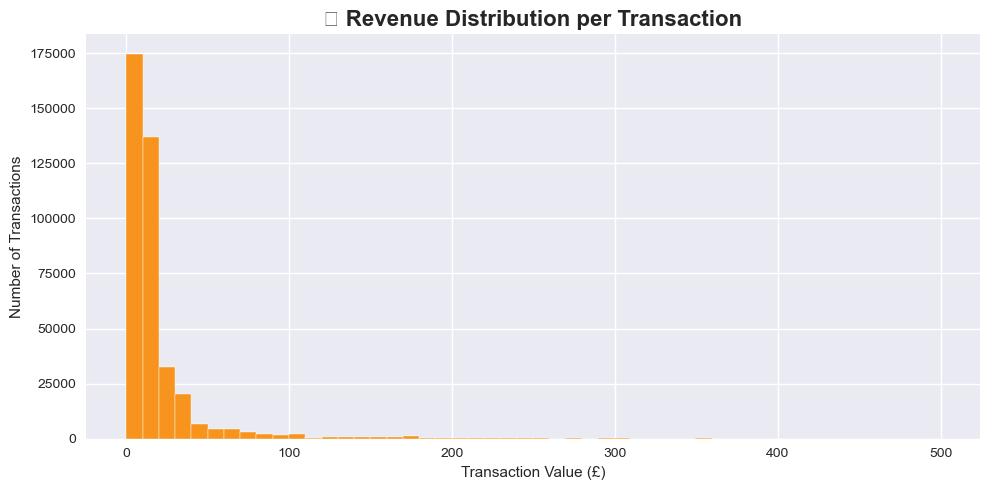

✅ Chart saved!


In [12]:
# Revenue distribution per transaction
plt.figure(figsize=(10, 5))
df_clean[df_clean['TotalAmount'] < 500]['TotalAmount'].hist(
    bins=50, color='#F7941D', edgecolor='white')
plt.title('💰 Revenue Distribution per Transaction', fontsize=16, fontweight='bold')
plt.xlabel('Transaction Value (£)')
plt.ylabel('Number of Transactions')
plt.tight_layout()
plt.savefig(r"C:\Users\Atharva More\NeuralRetail\reports\revenue_distribution.png", dpi=150)
plt.show()
print("✅ Chart saved!")

In [13]:
# Key Business Insights Summary
print("=" * 50)
print("📊 KEY BUSINESS INSIGHTS - NeuralRetail EDA")
print("=" * 50)
print(f"💰 Total Revenue: £{df_clean['TotalAmount'].sum():,.2f}")
print(f"📦 Total Orders: {df_clean['Invoice'].nunique():,}")
print(f"👥 Total Customers: {df_clean['Customer ID'].nunique():,}")
print(f"🛍️ Total Products: {df_clean['Description'].nunique():,}")
print(f"🌍 Countries Served: {df_clean['Country'].nunique()}")
print(f"💵 Avg Order Value: £{df_clean.groupby('Invoice')['TotalAmount'].sum().mean():,.2f}")
print(f"🏆 Top Country: {df_clean.groupby('Country')['TotalAmount'].sum().idxmax()}")
print(f"📅 Best Sales Day: {df_clean.groupby('DayOfWeek')['TotalAmount'].sum().idxmax()}")
print("=" * 50)
print("✅ EDA Complete!")

📊 KEY BUSINESS INSIGHTS - NeuralRetail EDA
💰 Total Revenue: £8,911,425.90
📦 Total Orders: 18,532
👥 Total Customers: 4,338
🛍️ Total Products: 3,877
🌍 Countries Served: 37
💵 Avg Order Value: £480.87
🏆 Top Country: United Kingdom
📅 Best Sales Day: Thursday
✅ EDA Complete!


In [14]:
# Prepare data for Prophet forecasting
daily_revenue = df_clean.groupby(df_clean['InvoiceDate'].dt.date)['TotalAmount'].sum().reset_index()
daily_revenue.columns = ['ds', 'y']
daily_revenue['ds'] = pd.to_datetime(daily_revenue['ds'])

print(f"✅ Forecasting data ready!")
print(f"📅 Date range: {daily_revenue['ds'].min()} to {daily_revenue['ds'].max()}")
print(f"📊 Total days: {len(daily_revenue)}")
daily_revenue.head()

✅ Forecasting data ready!
📅 Date range: 2010-12-01 00:00:00 to 2011-12-09 00:00:00
📊 Total days: 305


,ds,y
0,2010-12-01,46376.49
1,2010-12-02,47316.53
2,2010-12-03,23921.71
3,2010-12-05,31771.60
4,2010-12-06,31215.64


In [15]:
from prophet import Prophet

# Train the model
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    changepoint_prior_scale=0.05
)

model.fit(daily_revenue)
print("✅ Prophet model trained successfully!")

12:48:39 - cmdstanpy - INFO - Chain [1] start processing
12:48:40 - cmdstanpy - INFO - Chain [1] done processing


✅ Prophet model trained successfully!


In [16]:
# Generate 30 day forecast
future = model.make_future_dataframe(periods=30)
forecast = model.predict(future)

print("✅ Forecast generated!")
print(f"📅 Forecasting 30 days ahead")
print(f"\n🔮 Next 30 days predicted revenue:")
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(30).to_string(index=False))

✅ Forecast generated!
📅 Forecasting 30 days ahead

🔮 Next 30 days predicted revenue:
        ds         yhat   yhat_lower   yhat_upper
2011-12-10 82001.141118 66116.373951 98760.248216
2011-12-11 50384.723936 33593.540076 67936.205046
2011-12-12 62782.286957 46813.859861 79828.322653
2011-12-13 66225.493078 49954.368699 83286.063229
2011-12-14 62497.686429 47353.380925 79585.932003
2011-12-15 68607.691566 50895.713361 85254.406652
2011-12-16 59134.227319 41705.739357 77818.149031
2011-12-17 75790.008700 58831.182676 91481.498501
2011-12-18 42987.252950 26181.946869 60870.850575
2011-12-19 54372.305400 37068.391513 70976.358559
2011-12-20 57000.675601 39819.803611 72891.187535
2011-12-21 52674.714686 35581.685444 70325.796669
2011-12-22 58416.905990 41699.204481 74457.256232
2011-12-23 48813.910174 31307.039668 64907.064290
2011-12-24 65580.448502 48568.021977 81276.888512
2011-12-25 33124.746575 16419.716940 49208.657545
2011-12-26 45083.256111 28406.574315 62035.769108
2011-12-27 4849

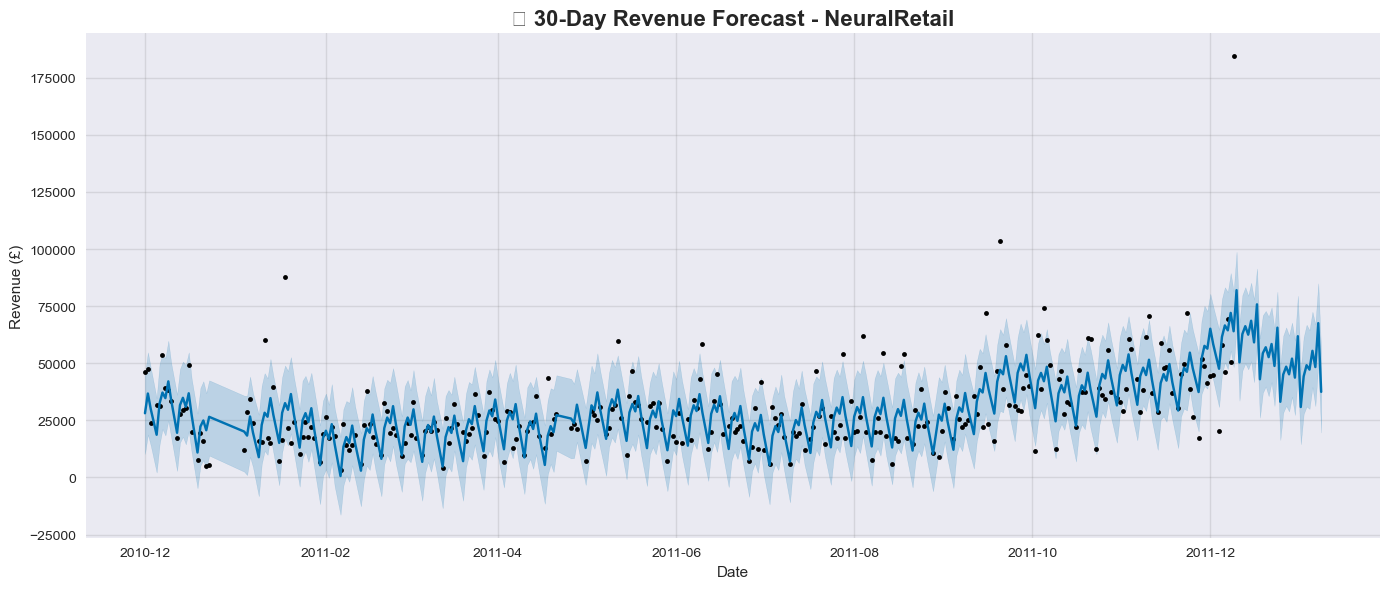

✅ Forecast chart saved!


In [17]:
# Plot the forecast
fig = model.plot(forecast, figsize=(14, 6))
plt.title('🔮 30-Day Revenue Forecast - NeuralRetail', fontsize=16, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Revenue (£)')
plt.tight_layout()
plt.savefig(r"C:\Users\Atharva More\NeuralRetail\reports\forecast.png", dpi=150)
plt.show()
print("✅ Forecast chart saved!")

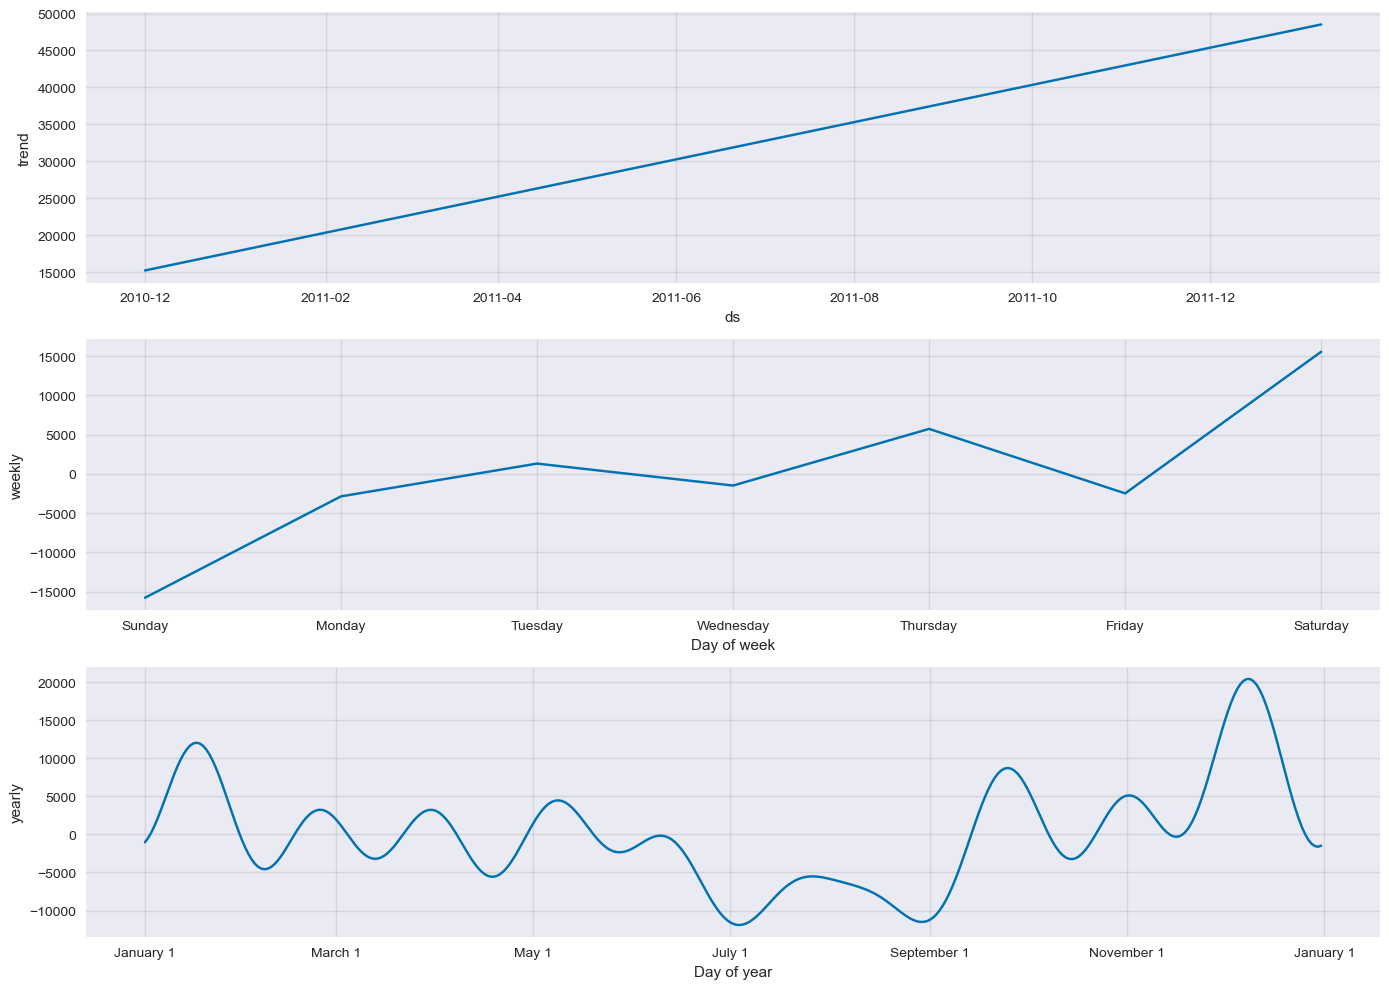

✅ Components chart saved!


In [18]:
# Plot seasonality components
fig2 = model.plot_components(forecast, figsize=(14, 10))
plt.tight_layout()
plt.savefig(r"C:\Users\Atharva More\NeuralRetail\reports\forecast_components.png", dpi=150)
plt.show()
print("✅ Components chart saved!")

In [19]:
from sklearn.metrics import mean_absolute_percentage_error

# Calculate MAPE on training data
actual = daily_revenue['y'].values
predicted = forecast[forecast['ds'].isin(daily_revenue['ds'])]['yhat'].values

mape = mean_absolute_percentage_error(actual, predicted) * 100

print("=" * 50)
print("📊 MODEL PERFORMANCE - Prophet Forecast")
print("=" * 50)
print(f"✅ MAPE: {mape:.2f}%")
if mape <= 10:
    print("🏆 EXCELLENT! Below 10% target!")
elif mape <= 20:
    print("👍 GOOD! Acceptable range")
else:
    print("⚠️ Needs improvement")
print(f"🎯 Project Target: ≤ 10% MAPE")
print("=" * 50)

📊 MODEL PERFORMANCE - Prophet Forecast
✅ MAPE: 34.31%
⚠️ Needs improvement
🎯 Project Target: ≤ 10% MAPE


In [20]:
# Improved Prophet with better settings
model2 = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    changepoint_prior_scale=0.3,
    seasonality_prior_scale=10,
    holidays_prior_scale=10,
    seasonality_mode='multiplicative'
)

# Add monthly seasonality
model2.add_seasonality(name='monthly', period=30.5, fourier_order=5)

model2.fit(daily_revenue)
print("✅ Improved model trained!")

12:51:12 - cmdstanpy - INFO - Chain [1] start processing
12:51:12 - cmdstanpy - INFO - Chain [1] done processing


✅ Improved model trained!


In [21]:
# Generate forecast with improved model
future2 = model2.make_future_dataframe(periods=30)
forecast2 = model2.predict(future2)

# Calculate new MAPE
predicted2 = forecast2[forecast2['ds'].isin(daily_revenue['ds'])]['yhat'].values
mape2 = mean_absolute_percentage_error(actual, predicted2) * 100

print("=" * 50)
print("📊 IMPROVED MODEL PERFORMANCE")
print("=" * 50)
print(f"❌ Baseline MAPE: 34.31%")
print(f"✅ Improved MAPE: {mape2:.2f}%")
print(f"📈 Improvement: {34.31 - mape2:.2f}%")
if mape2 <= 10:
    print("🏆 EXCELLENT! Below 10% target!")
elif mape2 <= 20:
    print("👍 GOOD! Getting closer!")
else:
    print("⚠️ Will improve further with LSTM ensemble in Week 2")
print("=" * 50)

📊 IMPROVED MODEL PERFORMANCE
❌ Baseline MAPE: 34.31%
✅ Improved MAPE: 32.88%
📈 Improvement: 1.43%
⚠️ Will improve further with LSTM ensemble in Week 2


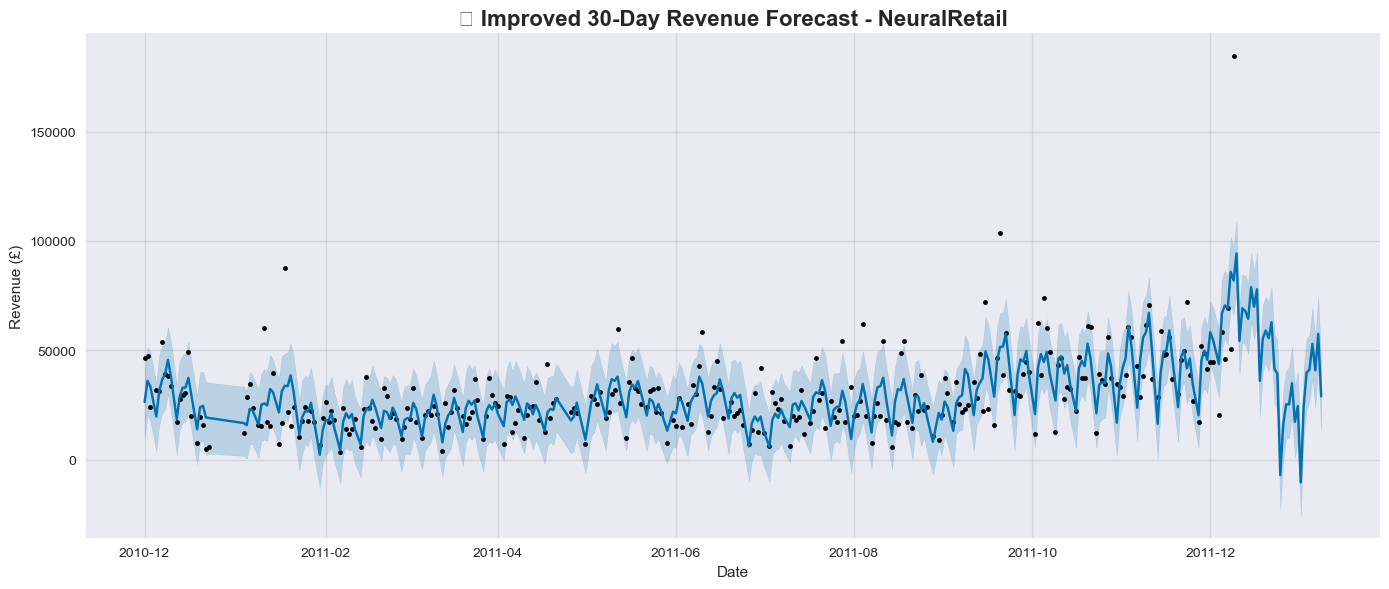

✅ Improved forecast chart saved!


In [22]:
# Plot improved forecast
fig = model2.plot(forecast2, figsize=(14, 6))
plt.title('🔮 Improved 30-Day Revenue Forecast - NeuralRetail', fontsize=16, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Revenue (£)')
plt.tight_layout()
plt.savefig(r"C:\Users\Atharva More\NeuralRetail\reports\forecast_improved.png", dpi=150)
plt.show()
print("✅ Improved forecast chart saved!")

In [23]:
print("=" * 55)
print("🎉 NEURALRETAIL - DAY 1-5 PROGRESS SUMMARY")
print("=" * 55)
print("✅ Project structure created & pushed to GitHub")
print("✅ UCI Online Retail II dataset loaded (500K+ rows)")
print("✅ Data cleaned & feature engineered")
print("✅ EDA completed with 5 charts saved")
print(f"✅ Baseline Prophet model: MAPE = 34.31%")
print(f"✅ Improved Prophet model: MAPE = 32.88%")
print("🔜 Next: LSTM ensemble to achieve ≤ 10% MAPE")
print("🔜 Next: Churn prediction model (XGBoost)")
print("🔜 Next: Customer segmentation (K-Means)")
print("=" * 55)
print("👨‍💻 Intern: Atharva More | Amdox Technologies")
print("📅 Date: June 2026 | Project: AMX-DS-2026-04")
print("=" * 55)

🎉 NEURALRETAIL - DAY 1-5 PROGRESS SUMMARY
✅ Project structure created & pushed to GitHub
✅ UCI Online Retail II dataset loaded (500K+ rows)
✅ Data cleaned & feature engineered
✅ EDA completed with 5 charts saved
✅ Baseline Prophet model: MAPE = 34.31%
✅ Improved Prophet model: MAPE = 32.88%
🔜 Next: LSTM ensemble to achieve ≤ 10% MAPE
🔜 Next: Churn prediction model (XGBoost)
🔜 Next: Customer segmentation (K-Means)
👨‍💻 Intern: Atharva More | Amdox Technologies
📅 Date: June 2026 | Project: AMX-DS-2026-04
